# 03 — Temporal evolution of the privilege ratio (Greek polities)

Privilege ratio = % of MORE rules in a (period × group) cell. 50 % is the
neutral line: above → the group is, on balance, gaining access; below →
losing access.

Rules whose rule-level polity is non-Greek (Rome, Persia, Carthage, Judea,
Christianity, Egypt, Syria, Stoic abstraction, mythological setting …) are
excluded.

**Source**: `data/processed_data/rules_final_dataset_130works_april_2026.tsv`
(1 011 gold-filtered rules).

*Follows `notebook_rule.md`: load at top, preprocess separately, one figure
per cell under `### Figure N`, no figures saved to disk.*

## 1. Setup — imports, style, constants

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

DATA = Path('../data/clean/final/rules_final_dataset_130works_april_2026.tsv')

# --- Period ordering / labels --------------------------------------------
PERIOD_ORDER = [
    'Classical (500–360 BCE)',
    'Late Classical (354–165 BCE)',
    'Hellenistic & Early Roman (165 BCE – 105 CE)',
    'High Roman Empire (135–205 CE)',
]
PERIOD_LABELS = [
    'Classical\n500–360 BCE',
    'Late Classical\n354–165 BCE',
    'Hellenistic &\nEarly Roman\n165 BCE – 105 CE',
    'High Roman\n135–205 CE',
]
PERIOD_SHORT = {
    'Classical (500–360 BCE)': 'Classical',
    'Late Classical (354–165 BCE)': 'Late Classical',
    'Hellenistic & Early Roman (165 BCE – 105 CE)': 'Hell. & E.Roman',
    'High Roman Empire (135–205 CE)': 'High Roman',
}

# --- Greek-polity filter --------------------------------------------------
NON_GREEK = {
    'Roman Empire', 'Roman Republic', 'Early Roman Republic',
    'Middle Roman Republic', 'Late Roman Republic', 'Early Roman Kingdom',
    'Republican Rome', 'Archaic Rome',
    'Achaemenid Empire', 'Carthage', 'Second Temple Judea',
    'Ancient Egypt', 'Late Period Egypt',
    'Hellenistic Hierapolis', 'Hierapolis (Syria)', 'Byblos (Syria)',
    'Scythia', 'Cilicia', 'Tarsus',
}
ABSTRACT_POLITY = {
    'Mythological / legendary setting',
    'Stoic Philosophy',
    'Non-Greek states',
    'Early Christian Church', 'Early Christian Community',
}
GREEK_MARKERS = (
    'athen', 'spart', 'greek', 'greec', 'hellen', 'macedon',
    'achae', 'corinth', 'thebe', 'syracus', 'miletus', 'ephes',
    'cret', 'rhod', 'delph', 'samos', 'aegin', 'ionia', 'thess',
    'locri', 'sicyon', 'mytil', 'argos', 'thrace', 'thurii',
    'megara', 'amphictyonic', 'league of corinth', 'elis',
    'mantineia', 'chalcidice', 'abdera', 'tarentum', 'cos',
    'agrigentum', 'elea', 'olbia', 'olympia', 'acragas',
    'samothrace', 'naucratis', 'cyme', 'croton', 'sinope',
    'archaic', 'classical', 'hellenistic', 'oreus', 'oropus',
)

# Drop the same small / noisy group buckets as 02_more_vs_less.
EXCLUDE_GROUPS = {
    'Soldiers', 'Artisans', 'Philosophers',
    'The multitude', 'Heirs', 'Priests',
}

# Minimum rules per (group × period) cell required to plot that point.
MIN_CELL_COUNT = 10

In [2]:
# Science-journal minimal style — defined once, used throughout.
plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'legend.frameon': False,
})

DEMO_STYLES = {
    'Women':   dict(color='#c0392b', marker='o', lw=2.0, ls='-'),
    'Men':     dict(color='#2980b9', marker='s', lw=2.0, ls='-'),
    'Minors':  dict(color='#e67e22', marker='D', lw=1.6, ls='--'),
}
STATUS_STYLES = {
    'Citizens':    dict(color='#2c6e91', marker='o', lw=2.0, ls='-'),
    'Slaves':      dict(color='#c0392b', marker='^', lw=2.0, ls='-'),
    'Foreigners':  dict(color='#d35400', marker='D', lw=1.6, ls='--'),
    'The wealthy': dict(color='#27ae60', marker='v', lw=1.6, ls='--'),
    'The poor':    dict(color='#f39c12', marker='P', lw=1.6, ls='--'),
    'Nobles':      dict(color='#8e44ad', marker='h', lw=1.6, ls='-.'),
}
COMBINED_STYLES = {**DEMO_STYLES, **STATUS_STYLES}

## 2. Load data

In [3]:
df_raw = pd.read_csv(DATA, sep='\t')
print(f'Loaded {len(df_raw):,} rules from {DATA.name}')
df_raw[['rule', 'directionality', 'group_meta', 'rule_polity',
        'work_polity', 'period', 'rule_date', 'author_impact_date']].head()

Loaded 1,011 rules from rules_final_dataset_130works_april_2026.tsv


,rule,directionality,group_meta,rule_polity,work_polity,period,rule_date,author_impact_date
0,Greek exclusion from large-scale statecraft,LESS,Greeks,Roman Empire,Roman Empire; Classical Greek poleis,Hellenistic & Early Roman (165 BCE – 105 CE),100,75
1,City-state local self-government,MORE,Greeks,Roman Empire,Roman Empire; Classical Greek poleis,Hellenistic & Early Roman (165 BCE – 105 CE),100,75
2,Noble access to magistracies,MORE,Nobles,Roman Empire,Roman Empire; Classical Greek poleis,Hellenistic & Early Roman (165 BCE – 105 CE),100,75
3,Citizen assembly voting,MORE,Citizens,Roman Empire,Roman Empire; Classical Greek poleis,Hellenistic & Early Roman (165 BCE – 105 CE),100,75
4,Proconsular annulment of local power,LESS,Citizens,Roman Empire,Roman Empire; Classical Greek poleis,Hellenistic & Early Roman (165 BCE – 105 CE),100,75


## 3. Preprocessing

Four steps, each logs its row count so every drop is traceable:

1. Keep only rated rules (MORE / LESS) with a known `group_meta` and
   `rule_polity`.
2. Keep only Greek-polity rules. Rules whose `rule_polity` is abstract
   (Stoic, mythological …) are kept iff their `work_polity` looks Greek.
3. Infer `period` when missing, via `rule_date` → `author_impact_date`.
4. Drop small / noisy group buckets.

In [4]:
n0 = len(df_raw)

# Step 1 — rated rules with group + rule_polity.
df = df_raw[df_raw['directionality'].isin(['MORE', 'LESS'])
            & df_raw['group_meta'].notna()
            & df_raw['rule_polity'].notna()].copy()
n1 = len(df)


# Step 2 — Greek polity filter with work-level fallback.
def is_greek_rule(row):
    rp = row['rule_polity']
    if rp in NON_GREEK:
        return False
    if rp in ABSTRACT_POLITY:
        wp = row.get('work_polity')
        if pd.isna(wp) or not str(wp).strip():
            return True
        wp_l = str(wp).lower()
        return any(m in wp_l for m in GREEK_MARKERS)
    return True


df['greek'] = df.apply(is_greek_rule, axis=1)
df = df[df['greek']].drop(columns='greek').copy()
n2 = len(df)


# Step 3 — infer period from rule_date / author_impact_date when missing.
def year_to_period(y):
    try:
        y = int(float(y))
    except (TypeError, ValueError):
        return np.nan
    if y <= -360:  return PERIOD_ORDER[0]
    if y <= -165:  return PERIOD_ORDER[1]
    if y <= 105:   return PERIOD_ORDER[2]
    if y <= 230:   return PERIOD_ORDER[3]
    return np.nan


def infer_period(row):
    if pd.notna(row.get('period')):
        return row['period']
    p = year_to_period(row.get('rule_date'))
    if isinstance(p, str):
        return p
    return year_to_period(row.get('author_impact_date'))


df['period'] = df.apply(infer_period, axis=1)
df = df[df['period'].notna()].copy()
n3 = len(df)


# Step 4 — drop small / noisy group buckets.
df = df[~df['group_meta'].isin(EXCLUDE_GROUPS)].copy()
n4 = len(df)

# Integrity checks.
assert df['period'].isin(PERIOD_ORDER).all(), 'stray period label'
assert df['directionality'].isin(['MORE', 'LESS']).all()

print(f'Raw:                                 {n0:,}')
print(f'After MORE/LESS + group + polity:    {n1:,}  (dropped {n0-n1})')
print(f'After Greek-polity filter:           {n2:,}  (dropped {n1-n2})')
print(f'After period inference:              {n3:,}  (dropped {n2-n3})')
print(f'After dropping small group buckets:  {n4:,}  (dropped {n3-n4})')
print(f'\n{df["group_meta"].nunique()} groups | '
      f'{df["rule_polity"].nunique()} rule-level polities | '
      f'{df["period"].nunique()} periods | '
      f'min cell count = {MIN_CELL_COUNT}')
df.head()

Raw:                                 1,011
After MORE/LESS + group + polity:    1,011  (dropped 0)
After Greek-polity filter:           898  (dropped 113)
After period inference:              898  (dropped 0)
After dropping small group buckets:  836  (dropped 62)

27 groups | 85 rule-level polities | 4 periods | min cell count = 10


,rule_uid,file_id,perseus_author,perseus_title,wikidata_work_id,wikidata_work_label,author_wikidata_id,author_impact_date,year,period,...,persistence_reasoning,group_immutability,immutability_reasoning,rule_contemporarity,contemporarity_reasoning,opinion_vs_fact,opinion_vs_fact_reasoning,tautology,tautology_reasoning,resource_type
5,tlg0007.tlg119.perseus-eng3::0,tlg0007.tlg119.perseus-eng3,Plutarch,"On Monarchy, Democracy, and Oligrachy",Q98582179,De amore,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,"Once granted, citizenship is typically lifelong.",3,Foreigners can acquire citizenship via state v...,0,Plutarch uses the Megarian example to define t...,5,Provides a clear definition of 'politeia' and ...,0,Being a 'foreigner' does not define the mechan...,Legal Standing; Political Power
6,tlg0007.tlg119.perseus-eng3::2,tlg0007.tlg119.perseus-eng3,Plutarch,"On Monarchy, Democracy, and Oligrachy",Q98582179,De amore,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Spartan 'homoioi' status was lifelong and stru...,5,Spartan nobility/eligibility was strictly tied...,1,Refers back to the Lycurgan establishment in S...,4,Reported as a factual feature of the Spartan c...,0,Being a noble does not inherently imply equal ...,Political Power
7,tlg0014.tlg059.perseus-eng2::0,tlg0014.tlg059.perseus-eng2,Demosthenes,Apollodorus Against Neaera,Q110665750,Against Onetor,Q117253,-348,-348,Late Classical (354–165 BCE),...,The status of being a senator/citizen enabled ...,4,Citizen status in Athens was a legal birth-sta...,0,Demosthenes is speaking about a contemporary l...,5,Verbatim describes a legal procedure as pure a...,0,Being a citizen does not define the specific p...,Political Power
8,tlg0014.tlg059.perseus-eng2::1,tlg0014.tlg059.perseus-eng2,Demosthenes,Apollodorus Against Neaera,Q110665750,Against Onetor,Q117253,-348,-348,Late Classical (354–165 BCE),...,The application of this fiscal rule is trigger...,3,The wealthy are defined by a changeable (thoug...,0,Demosthenes refers to current Athenian laws on...,5,States 'the laws prescribed' the fund allocati...,0,Being wealthy does not define the legislative ...,Material Wealth
9,tlg0014.tlg059.perseus-eng2::2,tlg0014.tlg059.perseus-eng2,Demosthenes,Apollodorus Against Neaera,Q110665750,Against Onetor,Q117253,-348,-348,Late Classical (354–165 BCE),...,"Atimia lasts until the debt is paid, often eff...",2,State debtors is a status acquired through a s...,0,Describes the active legal situation of the sp...,5,"States the legal consequences of debt (atimia,...",0,Debt does not conceptually mean 'loss of right...,Legal Standing; Political Power


## 4. Plotting helper

Builds a `(group × period)` privilege-ratio table and draws one line
per group, greying a point out when its cell has fewer than
`MIN_CELL_COUNT` rules.

In [5]:
def privilege_table(data, groups, min_total=MIN_CELL_COUNT):
    rows = []
    for g in groups:
        for p in PERIOD_ORDER:
            cell = data[(data['group_meta'] == g) & (data['period'] == p)]
            more = int((cell['directionality'] == 'MORE').sum())
            less = int((cell['directionality'] == 'LESS').sum())
            total = more + less
            ratio = 100 * more / total if total >= min_total else np.nan
            rows.append({'group': g, 'period': p,
                         'ratio': ratio, 'total': total})
    return (pd.DataFrame(rows)
              .pivot(index='group', columns='period', values='ratio')
              [PERIOD_ORDER])


def plot_temporal(groups, styles, title):
    pivot = privilege_table(df, groups)
    pivot = pivot[pivot.notna().sum(axis=1) >= 2]
    if pivot.empty:
        print(f'No groups with enough data for {title}')
        return
    pivot = pivot.loc[[g for g in groups if g in pivot.index]]

    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    x = np.arange(len(PERIOD_ORDER))

    ax.axhspan(50, 100, color='#eaf2f7', alpha=0.6, zorder=0)
    ax.axhspan(0, 50,  color='#fbeceb', alpha=0.6, zorder=0)
    ax.axhline(50, color='#333', linewidth=0.5, linestyle=':', alpha=0.6)

    for g in pivot.index:
        vals = pivot.loc[g].values
        valid = ~np.isnan(vals)
        s = styles.get(g, dict(color='#555', marker='o', lw=1.5, ls='-'))
        ax.plot(x[valid], vals[valid],
                marker=s['marker'], markersize=7, linewidth=s['lw'],
                color=s['color'], linestyle=s['ls'],
                markeredgecolor='white', markeredgewidth=1.2,
                label=g, zorder=3)
        last = np.where(valid)[0]
        if len(last):
            i = last[-1]
            ax.annotate(g, xy=(x[i], vals[i]),
                        xytext=(8, 0), textcoords='offset points',
                        color=s['color'], fontsize=9, fontweight='bold',
                        va='center')

    ax.text(0.01, 0.96, 'more privileged', transform=ax.transAxes,
            color='#2c6e91', fontsize=8, fontweight='bold',
            alpha=0.7, va='top')
    ax.text(0.01, 0.04, 'more excluded', transform=ax.transAxes,
            color='#c0392b', fontsize=8, fontweight='bold',
            alpha=0.7, va='bottom')

    ax.set_xticks(x)
    ax.set_xticklabels(PERIOD_LABELS, fontsize=8.5)
    ax.set_ylim(-2, 102)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
    ax.set_ylabel('privilege ratio (% MORE)')
    ax.set_xlim(-0.3, len(PERIOD_ORDER) - 0.3)
    ax.grid(axis='y', linestyle=':', linewidth=0.4, alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_title(title, loc='left', fontweight='bold', pad=8)
    fig.tight_layout()
    return fig, ax

## 5. Tables

### 5.1 Rule counts per group × period

In [6]:
TOP = list(DEMO_STYLES) + list(STATUS_STYLES)

_d = df[df['group_meta'].isin(TOP)].copy()
_d['p'] = _d['period'].map(PERIOD_SHORT)
counts = (_d.groupby(['group_meta', 'p']).size().unstack(fill_value=0)
            .reindex(index=TOP,
                     columns=[PERIOD_SHORT[p] for p in PERIOD_ORDER],
                     fill_value=0))
counts['Total'] = counts.sum(axis=1)
counts.loc['Total'] = counts.sum(axis=0)
counts

p,Classical,Late Classical,Hell. & E.Roman,High Roman,Total
group_meta,,,,,
Women,21,23,11,4,59
Men,18,18,3,1,40
Minors,14,18,6,0,38
Citizens,111,126,23,16,276
Slaves,22,40,6,2,70
Foreigners,24,32,12,4,72
The wealthy,37,57,7,5,106
The poor,4,42,1,1,48
Nobles,4,16,6,1,27


### 5.2 Per-period summary

Breakdown of rules, MORE vs LESS, distinct works, authors, groups.

In [7]:
rows = []
for p in PERIOD_ORDER:
    sub = df[df['period'] == p]
    n = len(sub)
    nm = int((sub['directionality'] == 'MORE').sum())
    nl = int((sub['directionality'] == 'LESS').sum())
    rows.append({
        'period': PERIOD_SHORT[p],
        'rules': n,
        'MORE (+)': nm,
        'LESS (−)': nl,
        '% positive': f'{100*nm/n:.0f}%' if n else '—',
        'works': sub['file_id'].nunique(),
        'authors': sub['perseus_author'].nunique(),
        'distinct groups': sub['group_meta'].nunique(),
    })
rows.append({
    'period': 'TOTAL',
    'rules': len(df),
    'MORE (+)': int((df['directionality'] == 'MORE').sum()),
    'LESS (−)': int((df['directionality'] == 'LESS').sum()),
    '% positive': f"{100*(df['directionality']=='MORE').sum()/len(df):.0f}%",
    'works': df['file_id'].nunique(),
    'authors': df['perseus_author'].nunique(),
    'distinct groups': df['group_meta'].nunique(),
})
pd.DataFrame(rows).set_index('period')

,rules,MORE (+),LESS (−),% positive,works,authors,distinct groups
period,,,,,,,
Classical,291,164,127,56%,45,10,22
Late Classical,411,216,195,53%,30,5,18
Hell. & E.Roman,97,50,47,52%,23,5,17
High Roman,37,19,18,51%,11,3,11
TOTAL,836,449,387,54%,107,21,27


## 6. Figures

### Figure 1: Demographic groups — Women, Men, Minors

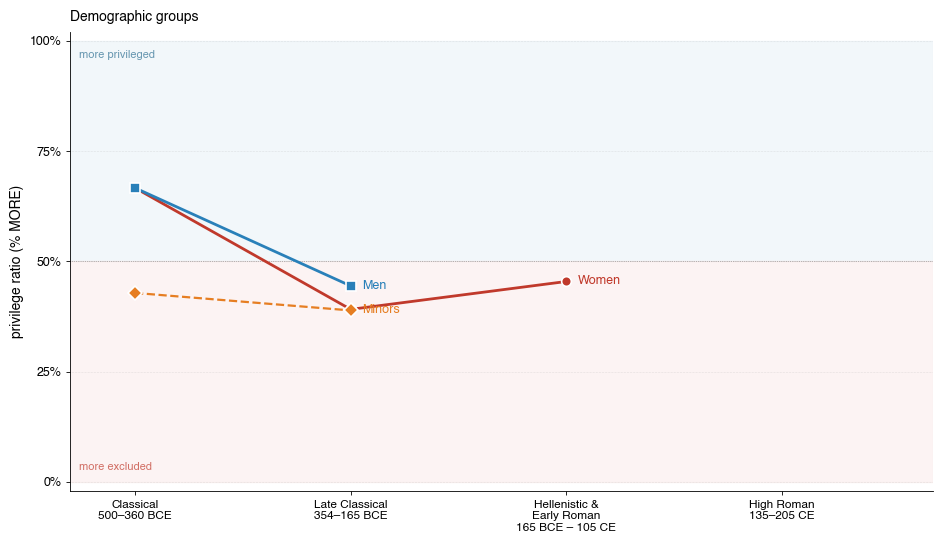

In [8]:
plot_temporal(list(DEMO_STYLES.keys()), DEMO_STYLES,
              title='Demographic groups');

### Figure 2: Social-status groups — Citizens, Slaves, Foreigners, wealthy, poor, Nobles

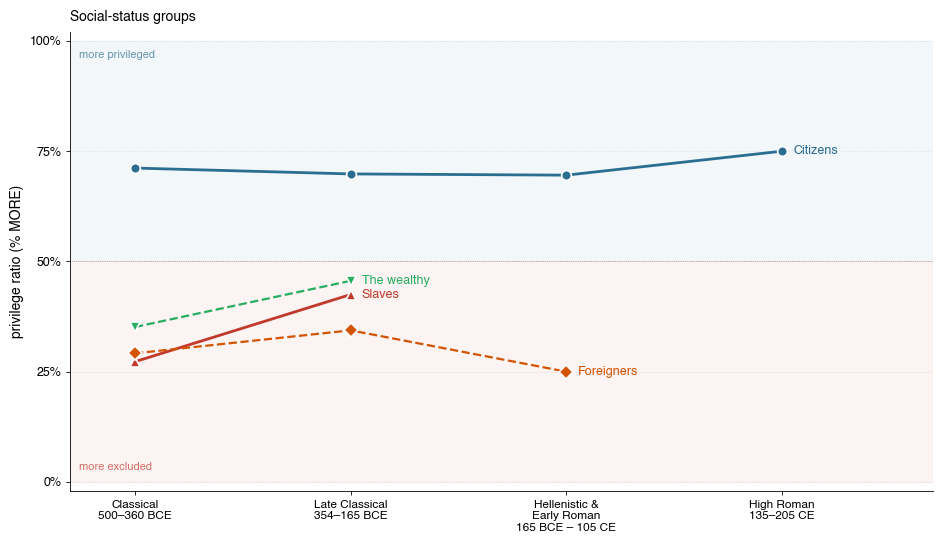

In [9]:
plot_temporal(list(STATUS_STYLES.keys()), STATUS_STYLES,
              title='Social-status groups');

### Figure 3: All top groups together

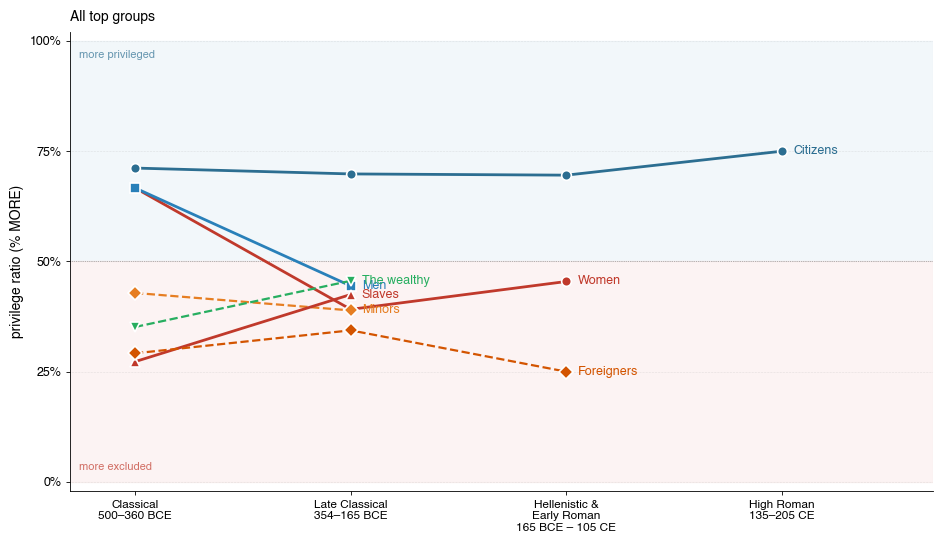

In [10]:
plot_temporal(list(COMBINED_STYLES.keys()), COMBINED_STYLES,
              title='All top groups');